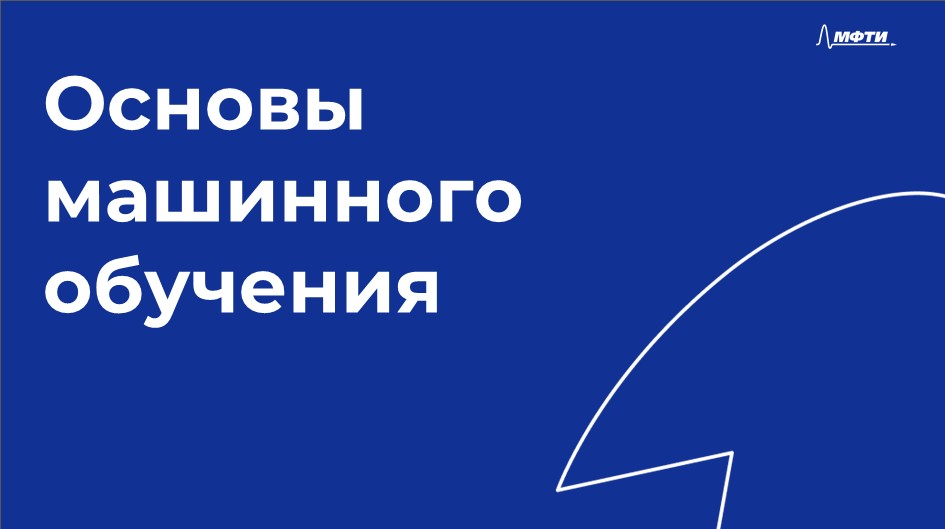

# 🎯 Неделя 2. Семинар 1.

**Сегодня в программе:**
1. Линейная регрессия и МНК.
2. Градиент и градиентный спуск.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

## 🟢 1. Линейная регрессия и МНК

Линейная регрессия (Linear Regression) — одна из простейших моделей для решения задачи регрессии. Главная гипотеза состоит в том, что рассматриваемая зависимость является линейной.

### Уравнение регрессии

Для начала поговорим о самом простом случае, когда  есть один фактор и зависящий от него целевой признак. Геометрически такая зависимость представляет собой координатную плоскость, где мы отмечаем точки по оси `x` и соответствующие им на оси `y`.

Представим, что есть данные по длинам плавников пингвинов и их массе тела.
Построим модель, которая опишет зависимость между этими признаками и позволит по известной длине плавников прогнозировать массу тела.

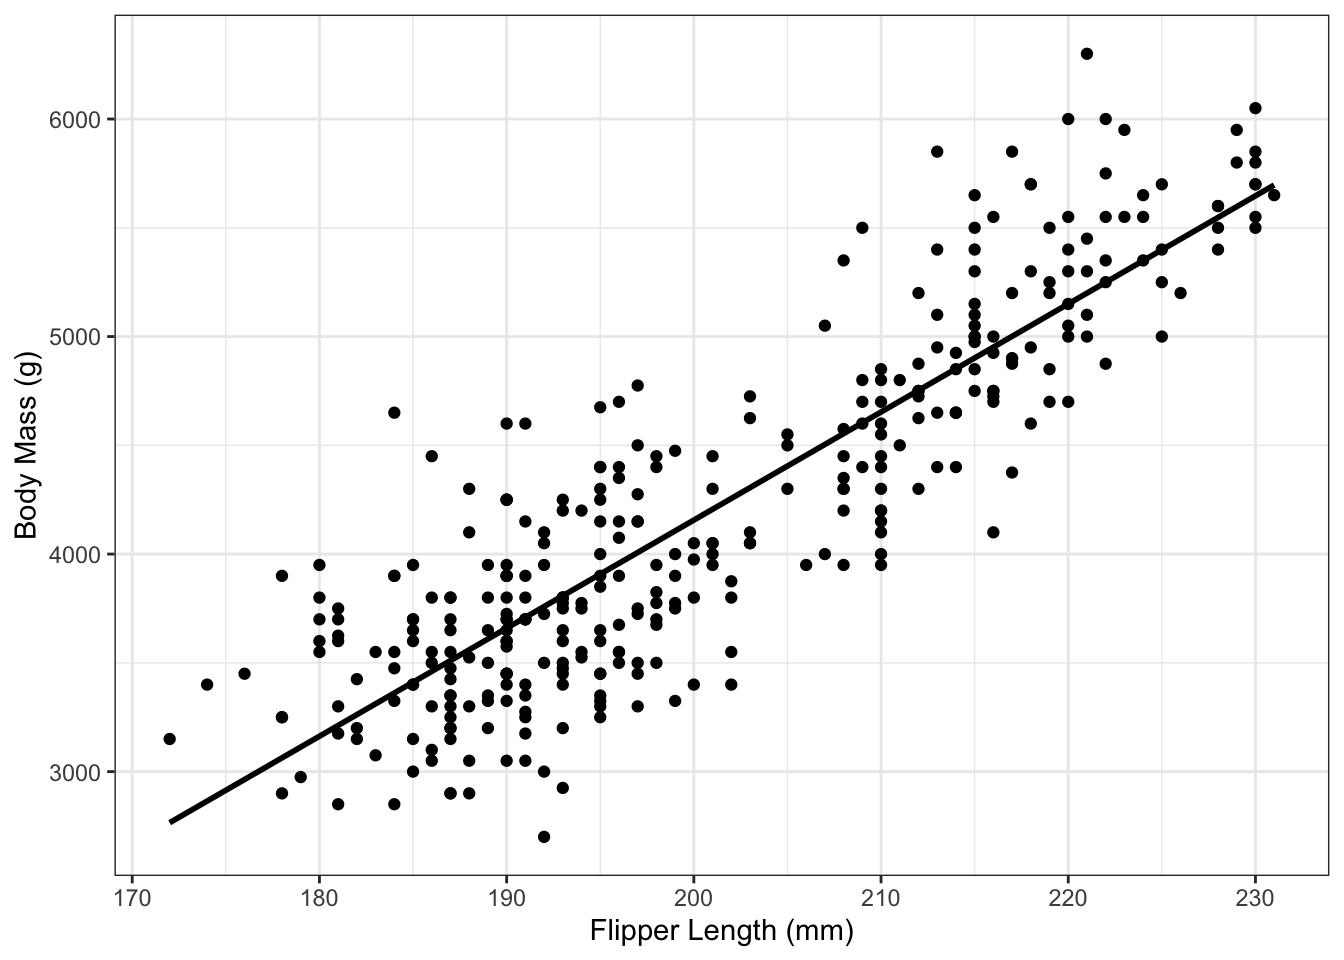

Из диаграммы отчётливо видно, что с ростом длины плавников растёт и масса тела. Причём растёт она преимущественно линейно: основная масса точек находится примерно на одной прямой.

Вспомним уравнение прямой из школьного курса математики:

$$y = k_{1} x_{1} + b$$

где:

- `x` — это некоторый фактор, от которого зависит целевая переменная `y`. В нашем случае, `x` — это длина плавников, а `y` — масса тела.  
- `k` — коэффициент наклона прямой (тангенс угла наклона). Если `k > 0`, это означает, что угол наклона прямой острый и прямая возрастает. Если `k < 0`, угол наклона тупой и прямая убывает.  
- `b` — коэффициент смещения прямой по оси `y`. Он будет соответствовать значению `y` при `b = 0`. То есть это точка пересечения прямой и оси `y`.  

А что если факторов не два, а больше? Тогда уравнение имеет вид:  
$$y = k_{1} x_{1} + k_{2} x_{2} + k_{3} x_{3} + ... k_{n} x_{n} +b$$

В геометрическом смысле данное уравнение описывает плоскость в n-мерном пространстве. Такую плоскость называют гиперплоскостью.

Как правило, в реальных задачах факторов больше двух, поэтому отобразить модель в двумерном пространстве не получится.



### МНК

Но как подобрать ту самую прямую, которая максимально хорошо будет описывать данные?

Ведь её можно провести как угодно, при том, что лучший результат только один. Математически мы пытаемся с помощью методов оптимизации найти такие параметры, чтобы ошибка была наименьшей из возможных.



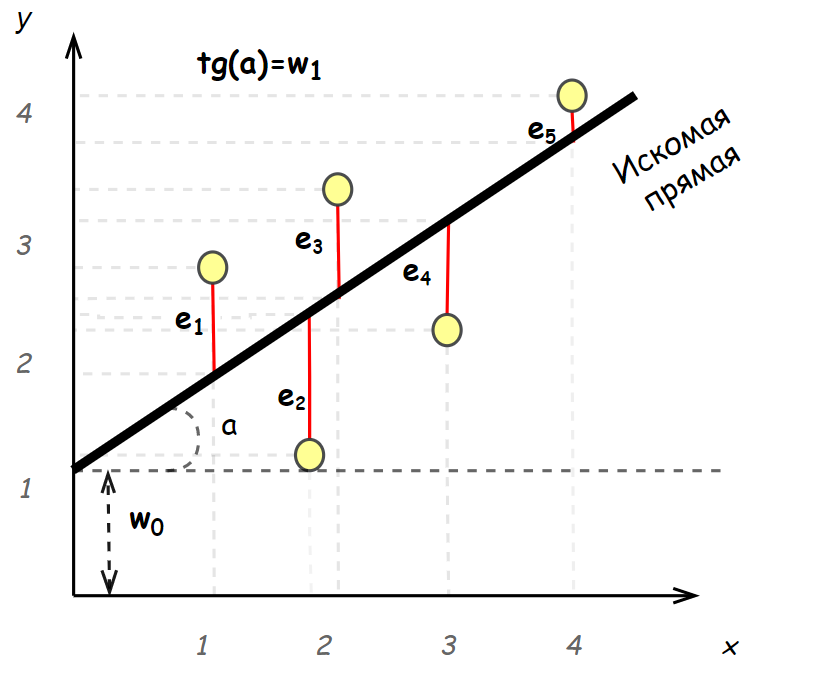

Математике известно решение данной задачи оптимизации. Метод поиска параметров линейной регрессии называется **методом наименьших квадратов** (сокращённо — МНК) и был изобретён Гауссом ещё в 1795 году. В английской литературе часто можно встретить аббревиатуру OLS (Ordinary Least Squares).




#### Вывод МНК

Метод наименьших квадратов (МНК) используется в задачах регрессии, когда качество модели оценивается с помощью суммы квадратов отклонений предсказанных значений от истинных. Такая ситуация естественно возникает при работе с переопределённой системой линейных уравнений (когда число уравнений больше числа неизвестных и точного решения не существует).

Пусть задана система
$$
Ax = b,
$$
где $A$ — матрица признаков, $x$ — вектор неизвестных параметров модели, $b$ — вектор истинных значений. Цель состоит в том, чтобы найти такой вектор $x$, при котором предсказания $Ax$ как можно ближе к $b$.

Для этого вводится функция ошибки — сумма квадратов отклонений:
$$
L(x) = \sum_{i=1}^{m} (A_i x - b_i)^2 = \|Ax - b\|^2.
$$

Задача МНК сводится к минимизации этой функции. Так как $L(x)$ является квадратичной и гладкой функцией, её минимум можно найти аналитически. Для этого вычисляют градиент по $x$ и приравнивают его к нулю:
$$
\nabla_x \|Ax - b\|^2 = 0.
$$

После раскрытия производной получается система нормальных уравнений:
$$
A^T A x = A^T b.
$$

Если матрица $A^T A$ обратима, решение задачи МНК имеет явный вид:
$$
x = (A^T A)^{-1} A^T b.
$$

Таким образом, метод наименьших квадратов даёт оптимальные параметры линейной модели в смысле минимизации средней квадратичной ошибки. В машинном обучении это аналитическое решение соответствует обучению линейной регрессии с функцией потерь MSE.


#### Практика

Рассмотрим данные компании, которая продаёт одежду через онлайн-приложение и оффлайн в магазинах с консультациями стилистов. Клиенты посещают магазин, получают консультацию, а затем оформляют покупки через мобильное приложение или веб-сайт.

Используемые признаки:
- **Avg. Session Length** — среднее время оффлайн-консультации со стилистом  
- **Time on App** — среднее время в мобильном приложении  
- **Time on Website** — среднее время на сайте  
- **Length of Membership** — длительность пользования сервисом (в годах)

Для существующих клиентов модель позволяет:
- прогнозировать будущий доход;
- оценить вклад каждого канала взаимодействия в целевую переменную.

In [7]:
df = pd.read_csv('ecommerce.csv')
print(df.shape)
df.head()

(500, 8)


,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [9]:
# сразу уберем неинформативные признаки
df = df.drop(columns=['Email', 'Address', 'Avatar'])
df.head()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,34.497268,12.655651,39.577668,4.082621,587.951054
1,31.926272,11.109461,37.268959,2.664034,392.204933
2,33.000915,11.330278,37.110597,4.104543,487.547505
3,34.305557,13.717514,36.721283,3.120179,581.852344
4,33.330673,12.795189,37.536653,4.446308,599.406092


Модель линейной регрессии (как и многие другие) требует, чтобы в подаваемых ей на вход данных не было пропущенных значений. Поэтому если в ваших данных окажутся пропуски, нужно их заранее предобработать.

К выбросам модель также крайне чувствительна!


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Avg. Session Length   500 non-null    float64
 1   Time on App           500 non-null    float64
 2   Time on Website       500 non-null    float64
 3   Length of Membership  500 non-null    float64
 4   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5)
memory usage: 19.7 KB


In [11]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


Построим `pairplot`, чтобы выдвинуть гипотезы о взаимосвязи признаков.

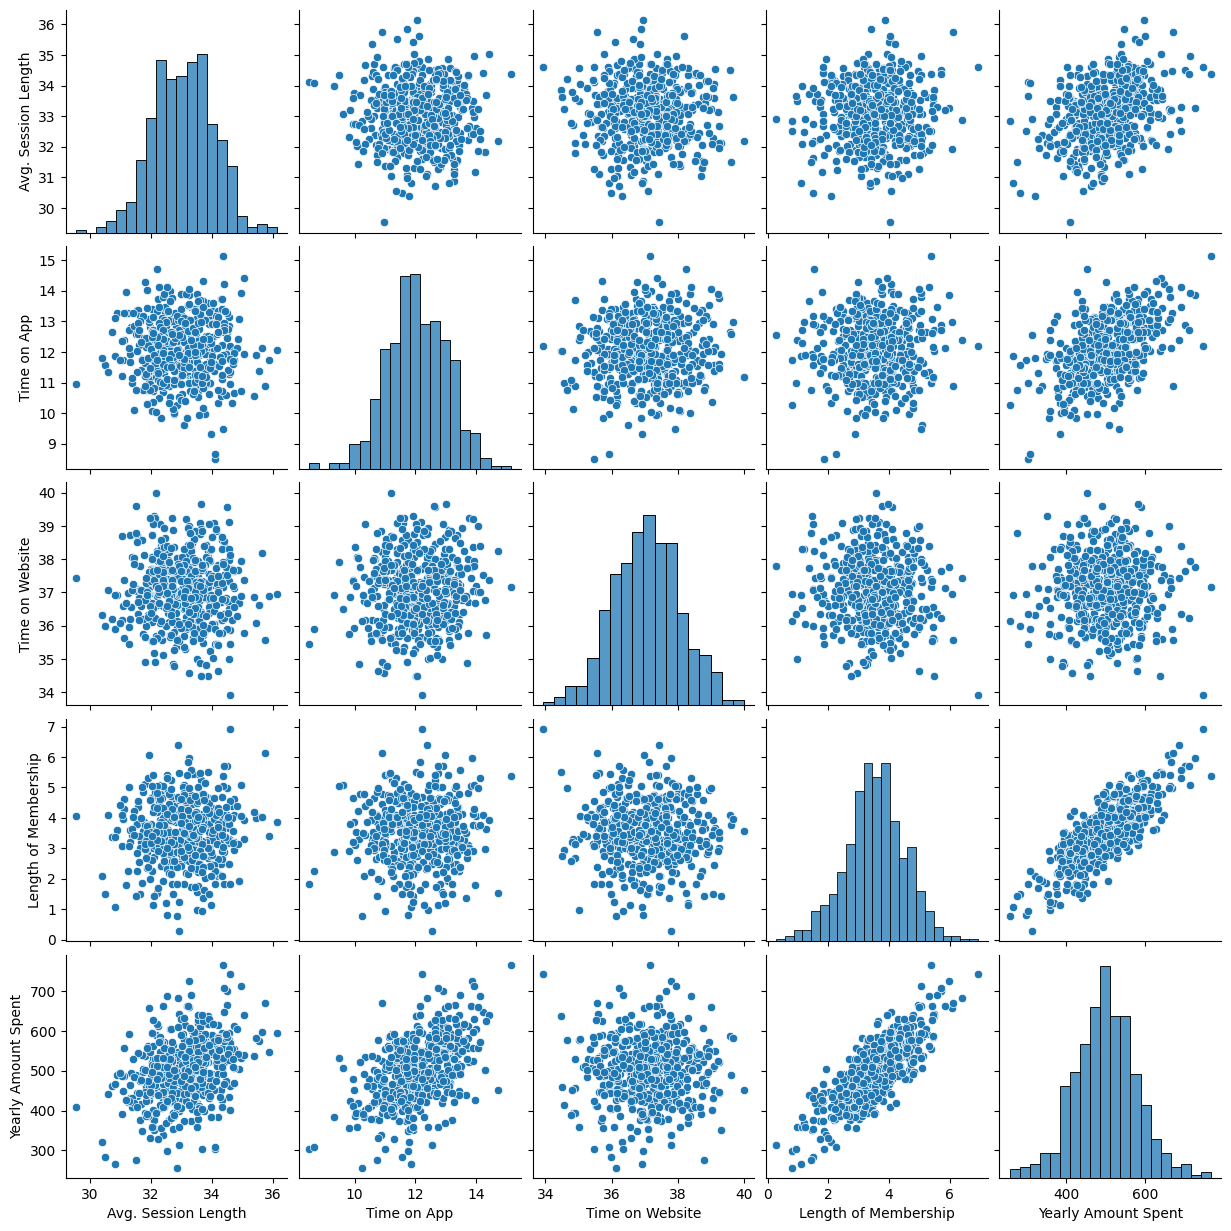

In [12]:
sns.pairplot(df)

Начнём с базы. Построим линейную регрессию на одном признаке. Выберем признак, который имеет наиболее высокую линейную взаимосвязь. Для этого рассчитаем корреляцию признаков с целевой переменной и выберем наиболее влиятельный.



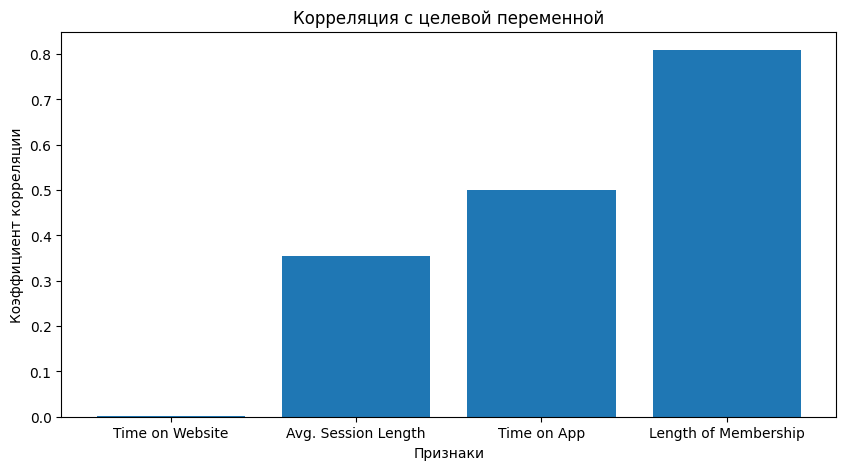

In [13]:
# вычисляем модуль корреляции
corr_with_target = df.corr()['Yearly Amount Spent'].abs().sort_values()

# удаляем корреляцию целевой переменной с самой собой
corr_with_target = corr_with_target.drop('Yearly Amount Spent')

# строим столбчатую диаграмму корреляций
plt.figure(figsize=(10, 5))
plt.bar(corr_with_target.index, corr_with_target.values)
plt.title('Корреляция с целевой переменной')
plt.xlabel('Признаки')
plt.ylabel('Коэффициент корреляции')
plt.show()

Итак, самый коррелированный по модулю   признак — `Length of Membership`. Давайте построим линейную регрессию **вручную**, используя только этот признак.



In [15]:
def least_squares_solution(X, y):
    """
    Решение линейной регрессии методом наименьших квадратов:
    w = (X^T X)^{-1} X^T y
    """
    # добавляем столбец единиц для bias
    X_bias = np.c_[np.ones(X.shape[0]), X]

    # нормальные уравнения
    # Запишите сюда решение линейной регрессии (показано выше)
    w = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y
    return w

In [16]:
X = df[['Length of Membership']].values # признаки всегда должны быть многомерным массивом
y = df['Yearly Amount Spent'].values

# обучение модели
w = least_squares_solution(X, y)

w0, w1 = w
print(f"bias (w0): {w0:.3f}")
print(f"coef (w1): {w1:.3f}")

bias (w0): 272.400
coef (w1): 64.219


Теперь обратимся к `sklearn`: в модуле `linear_model` находится класс [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html), который также реализует аналитическое решение линейной регрессии.


In [17]:
reg = LinearRegression() # создаем объект линейной регрессии

Обучение модели в `sklearn` производится посредством вызова метода `.fit(X, y)`.

Чтобы получить свободный член нужно обратиться по атрибуту `intercept_`, а вектор параметров будет храниться в атрибуте `coef_`.


In [18]:
reg.fit(X, y) # обучаем модель на данных

print(reg.coef_)
print(reg.intercept_)

[64.21868432]
272.39978605802816


То есть наше уровнение регрессии имеет вид:

`y = 64.22 * Length_of_Membership + 272.4`

Для составления прогноза используется метод `.predict(X)`, он позволяет получить предсказания для каждого объекта из переданного массива.

In [19]:
# Составим предсказания алгоритма на имеющихся данных
y_pred_simple = reg.predict(X)
y_pred_simple.shape

(500,)

Как будет отличаться код, если мы хотим сделать прогноз на основе всех признаков? Почти никак :)

In [20]:
X = df[['Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership']]
y = df['Yearly Amount Spent']

lr_full = LinearRegression()
lr_full.fit(X, y)
y_pred_full = lr_full.predict(X)
y_pred_full.shape

(500,)

Для удобства составим DataFrame из коэффициентов обученной модели.

In [22]:
lr_df = pd.DataFrame({'Признаки': X.columns, 
                      'Коэффициенты': lr_full.coef_})

intercept_df = pd.DataFrame({'Признаки': ['Intercept'], 
                             'Коэффициенты': lr_full.intercept_})
# Соедините lr_df и intercept_df
coef_df = pd.concat([lr_df, intercept_df], ignore_index=True)
coef_df

,Признаки,Коэффициенты
0,Avg. Session Length,25.734271
1,Time on App,38.709154
2,Time on Website,0.436739
3,Length of Membership,61.577324
4,Intercept,-1051.594255


Каждый из коэффициентов показывает, на сколько в среднем (согласно модели) изменится траты клиента в год при увеличении параметра на единицу.

Cвободный член (Intercept) имитирует влияние внешних факторов и носит смысл «поправки» модели относительно медианной стоимости.



Может показаться, что чем больше коэффициент регрессии по модулю, тем важнее признак. Это неверно.

Величина коэффициента зависит от **единиц измерения и масштаба признака**. Если признаки измеряются в разных единицах или имеют разный масштаб, их коэффициенты нельзя напрямую сравнивать.

*Пример: предсказываем цену квартиры по площади и количеству комнат.*

| Площадь (м^2) | Комнаты | Цена (млн) |
|--------------|---------|------------|
| 40           | 1       | 5          |
| 50           | 2       | 7          |
| 60           | 3       | 9          |
| 70           | 4       | 11         |

Модель:
$$
y = 0.1 x_1 + 1 x_2
$$
где $x_1$ — площадь, $x_2$ — количество комнат.

Коэффициент при $x_2$ больше, но это не означает, что комнаты важнее площади. Причина — разные единицы измерения.

Если измерить площадь в см^2, получим:
$$
y = 0.0001 x_1 + 1 x_2
$$

Коэффициент при площади уменьшился, но влияние признака на модель не изменилось.

Вывод: **коэффициенты регрессии корректно сравнивать только после масштабирования признаков**!

In [23]:
scaler = StandardScaler()

# Подбираем параметры стандартизатора (вычисляем среднее и СКО)
scaler.fit(X)

# Производим стандартизацию тренировочной выборки
X_scaled = scaler.transform(X)
X_scaled

array([[ 1.45635117,  0.60728003,  2.49358859,  0.55010651],
       [-1.13650215, -0.94946372,  0.20655573, -0.87092735],
       [-0.05272322, -0.72713923,  0.04968115,  0.5720669 ],
       ...,
       [-0.40987204, -0.55685385,  1.26018697,  1.42726105],
       [ 0.27159708,  0.34124841, -0.21829075, -1.19904197],
       [ 0.66842216,  0.36882066, -1.27732288, -0.79967926]],
      shape=(500, 4))

In [24]:
lr_scaled = LinearRegression()
lr_scaled.fit(X_scaled, y)
y_pred_scaled = lr_scaled.predict(X_scaled)
y_pred_scaled.shape

(500,)

In [25]:
lr_df = pd.DataFrame({'Признаки': X.columns, 'Коэффициенты': lr_scaled.coef_})

intercept_df = pd.DataFrame({'Признаки': ['Intercept'], 'Коэффициенты': lr_scaled.intercept_})
coef_df = pd.concat([lr_df, intercept_df], ignore_index=True)
coef_df

,Признаки,Коэффициенты
0,Avg. Session Length,25.517332
1,Time on App,38.446740
2,Time on Website,0.440878
3,Length of Membership,61.471271
4,Intercept,499.314038


Посмотрим ещё на остатки модели:

<Axes: xlabel='Yearly Amount Spent', ylabel='Count'>

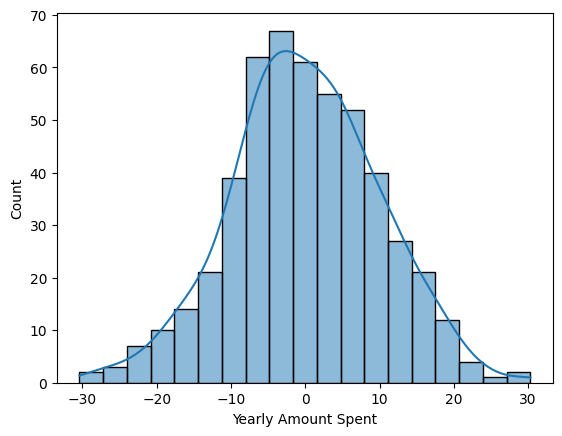

In [26]:
sns.histplot((y-y_pred_scaled), kde=True)

Если остатки распределены не нормально, то:
- возможно, некоторые важные переменные не включены в модель, или не учитываются важные нелинейные зависимости.
- в данных присутствуют выбросы, которые могут существенно влиять на качество прогнозов.


## 🟢 2. Градиент и градиентный спуск
Прежде вспомним **геометрический смысл производных в "2D"**:
- Производная отражает скорость роста функции.
- Производная также является некоторой одномерной функцией (от одной переменной).
- Значение производной в точке == коэффициент наклона касательной к функции в этой точке.

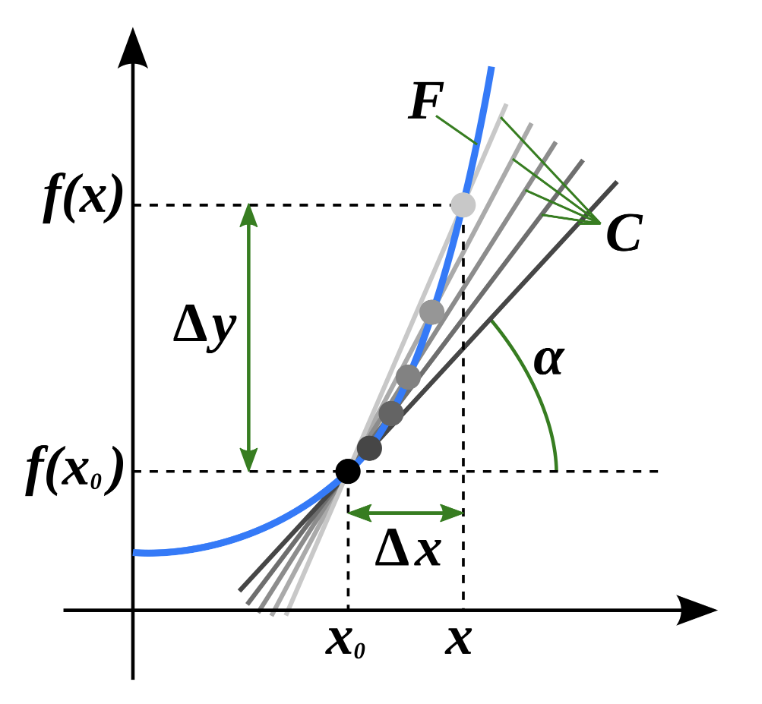



А теперь перейдём к рассмотрению **геометрического смысла частных производных**:

- Рассчитываем уже не одну производную, а две частные производные – в отдельности для каждой переменной.
- По-прежнему, каждая частная производная отражает скорость роста функции, но по соответствующей переменной.
- Это некоторая двумерная функция (от двух переменных)
- Значения каждой частной производной в точке == коэффициент наклона одной из касательных прямых. На них можно однозначно визуализировать касательную плоскость!

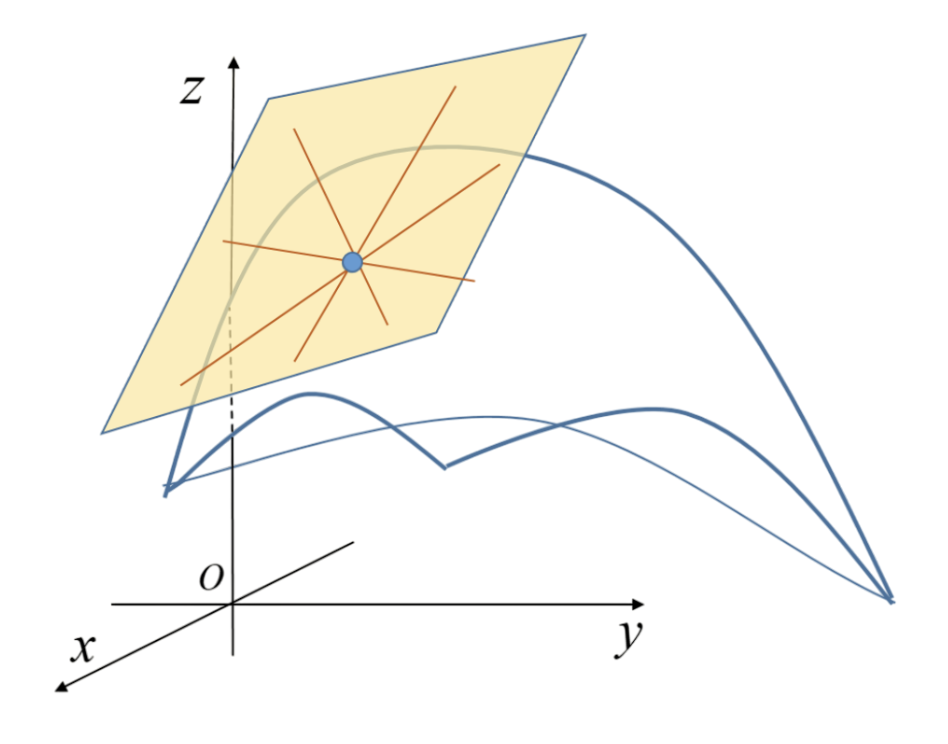

А вектор градиента - это лишь упорядоченный набор частных производных.

У него есть прекрасное свойство: **вектор градиента указывает направление наибольшего увеличения функции, а его длина определяет скорость роста функции в этом направлении**. Из этого следует, что **антиградиент показывает направление наискорейшего убывания функции** - это свойство как раз используется для оптимизации **функции потерь**, которая является *мерой различия между предсказанными моделью значениями и фактическим таргетом*.

Обозначение вектора градиента по частным производным выглядит так:

$$\nabla f = \left(\frac{\partial f}{\partial w_1}, \frac{\partial f}{\partial w_2}, \dots, \frac{\partial f}{\partial w_n}\right)$$

где $f$ - функция нескольких переменных, $w_1, w_2, \dots, w_n$ - ее аргументы.

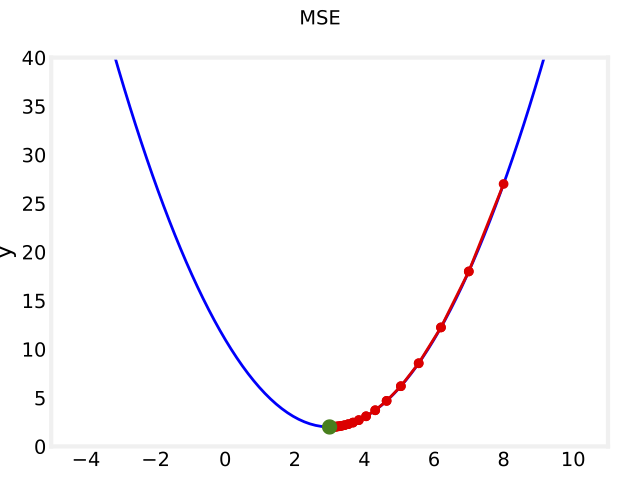

Формула для градиента линейной регрессии:
```python
    gradient = (1/n) * X.T.dot(errors)
```
Давайте посмотрим, как она выводится для MSE.

Пусть у нас есть обучающий набор данных с $n$ наблюдениями и $d$ признаками. Каждое наблюдение $i$ имеет $d$ признаков $x_{i1}, x_{i2}, ..., x_{id}$ и соответствующий целевой признак $y_i$. Задача линейной регрессии состоит в том, чтобы найти линейную функцию, которая наилучшим образом соответствует данным. Мы можем записать модель линейной регрессии следующим образом:

$$
\hat{y} = f(x) = w_0 + w_1 x_1 + w_2 x_2 + \cdots + w_d x_d = \sum_{j=0}^{d-1} w_j x_j,
$$

где $\hat{y}$ - это предсказанный ответ, $w_j$ - это веса (коэффициенты) для каждого признака, а $x_j$ - это значение признака $j$ для данного наблюдения.

MSE - это среднее значение квадрата разности между предсказанным значением $\hat{y_i}$ и истинным значением $y_i$ для каждого наблюдения $i$ в обучающем наборе:

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^n (\hat{y_i} - y_i)^2.
$$

Теперь мы можем найти градиент MSE по весам $w_j$, чтобы обновить их в процессе обучения. Градиент MSE по $w_j$ можно записать следующим образом:

$$
\frac{\partial \text{MSE}}{\partial w_j} = \frac{\partial}{\partial w_j} \frac{1}{n} \sum_{i=1}^n (\hat{y_i} - y_i)^2.
$$

Далее мы можем использовать правило цепочки, чтобы найти этот градиент:

$$
\frac{\partial \text{MSE}}{\partial w_j} = \frac{2}{n} \sum_{i=1}^n (\hat{y_i} - y_i) \frac{\partial \hat{y_i}}{\partial w_j}.
$$

Теперь нам нужно найти производную $\frac{\partial \hat{y_i}}{\partial w_j}$. Мы можем заметить, что $\hat{y_i}$ является линейной комбинацией весов $w_j$ и признаков $x_j$, поэтому производная по $w_j$ просто равна соответствующему признаку.

Если $j=0$, то

$$
\frac{\partial}{\partial w_j} \left(\sum_{k=0}^d w_k x_{ik}\right) = \frac{\partial}{\partial w_0} (w_0 + w_1 x_{i1} + \cdots + w_d x_{id}) = 1.
$$

Если $j \neq 0$, то

$$
\frac{\partial}{\partial w_j} \left(\sum_{k=0}^d w_k x_{ik}\right) = \frac{\partial}{\partial w_j} (w_0 x_{i0} + w_1 x_{i1} + \cdots + w_j x_{ij} + \cdots + w_d x_{id}) = x_{ij}.
$$

Таким образом, мы можем записать градиент MSE по $w_j$ следующим образом:

$$
\frac{\partial \text{MSE}}{\partial w_j} = \frac{2}{n} \sum_{i=1}^n (\hat{y_i} - y_i) x_{ij}, \qquad j = 0, 1, \ldots, d-1.
$$

Эта формула градиента позволяет обновлять веса $w_j$ в процессе обучения, используя градиентный спуск или его вариации. В частности, мы можем использовать эту формулу для обучения линейной регрессии методом наименьших квадратов или стохастическим градиентным спуском.

**Простейший случай: смещение и один признак**

Модель: $m(x) = w_0 + w_1 x$

Параметры: $w_0 , w_1$

Функционал ошибки: $Q(w_0, w_1) = \frac{1}{n} \sum_{i=1}^n (w_1 x_i + w_0 - y_i)^2$

Первая компонента вектора градиента: $\frac{\partial \text{Q}}{\partial w_0} = \frac{2}{n} \sum_{i=1}^n (w_1 x_i + w_0 - y_i) 1$

Первая компонента вектора градиента: $\frac{\partial \text{Q}}{\partial w_1} = \frac{2}{n} \sum_{i=1}^n (w_1 x_i + w_0 - y_i) x_{i1}$

Вектор градиента: $\nabla Q(w_0, w_1) = (\frac{2}{n} \sum_{i=1}^n (w_1 x_i + w_0 - y_i) 1, \frac{2}{n} \sum_{i=1}^n (w_1 x_i + w_0 - y_i) x_{i1}) $

**Общий случай: d признаков**

Модель: $m(x) = w_0 + w_1 x_1 + \dots + w_{d - 1} x_{d - 1}$

Параметры: $w_0, w_1, \dots , w_{d - 1}$

Функционал ошибки: $Q(w_0, \dots, w_{d - 1}) = \frac{1}{n} \sum_{i=1}^n (w_0 \cdot 1 + w_1 \cdot 1 x_{i1} + \dots +  w_{d-1} \cdot x_{id-1} - y_i)^2$

Первая компонента вектора градиента: $\frac{\partial \text{Q}}{\partial w_0} = \frac{2}{n} \sum_{i=1}^n (w_0 \cdot 1 + w_1 \cdot 1 x_{i1} + \dots +  w_{d-1} \cdot x_{id-1} - y_i) 1$

...

$d$-я компонента вектора градиента: $\frac{\partial \text{Q}}{\partial w_{d-1}} = \frac{2}{n} \sum_{i=1}^n (w_0 \cdot 1 + w_1 \cdot 1 x_{i1} + \dots +  w_{d-1} \cdot x_{id-1} - y_i) x_{id-1}, \qquad j = 0, 1, \ldots, d-1$

Вектор градиента: $\nabla Q(w) = \frac{2}{n} X^T (X \cdot w - y) $

In [27]:
def predict(X, weights):
    """
    Расчёт предсказания модели
    """
    return X @ weights

def mse_loss(y_true, y_pred):
    """
    Расчёт значения функции ошибки MSE
    """
    return np.mean((y_true - y_pred) ** 2)

In [28]:
def gradient_descent(
    X, y, lr=0.1, n_iter=1000, calc_loss=True, print_loss=True
):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features) # начальное приближение
    losses = []

    for i in range(n_iter):
        # предсказание
        y_pred = predict(X, weights)

        # градиент
        error = y_pred - y
        grad = (2 / n_samples) * X.T @ error

        # обновление весов
        weights = weights - lr * grad

        # расчёт и сохранение ошибки
        if calc_loss:
            loss = mse_loss(y, y_pred)
            losses.append(loss)

            # промежуточные выводы на экран
            if print_loss and i % 10 == 0:
                print(f"Iteration {i}: MSE = {loss:.4f}")

    return weights, losses

In [29]:
def plot_history(losses):
    """
    Визуализация графика сходимости
    (значение loss в зависимости от номера итерации)
    """
    plt.plot(losses)
    plt.xlabel("Iteration")
    plt.ylabel("MSE Loss")
    plt.title("График сходимости градиентного спуска")
    plt.grid(True)
    plt.show()

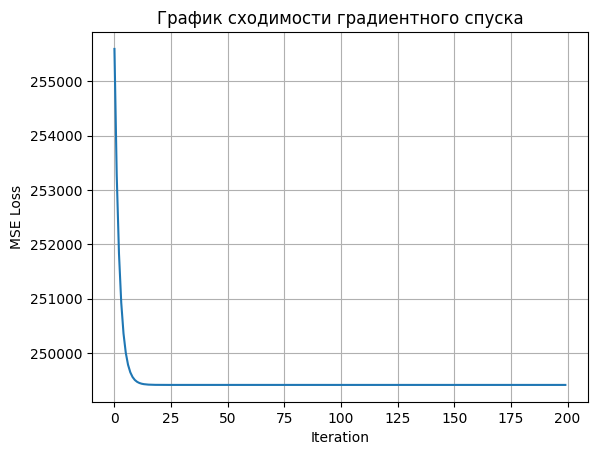

[25.5173325  38.4467404   0.44087821 61.47127066]


In [30]:
weights, losses = gradient_descent(
    X_scaled, y, lr=0.1, n_iter=200, calc_loss=True, print_loss=False
)
plot_history(losses) # визуализация истории обучения
print(weights) # веса

# считаем предсказания
preds_gd = predict(X_scaled, weights)

В чем недостатки такого подхода? Классический градиентный спуск обновляет параметры только после вычисления градиента по **всей обучающей выборке**.

Недостатки:

* Очень медленно на больших данных.
* Может "застревать" в локальных минимумах или плато.
* Требует много памяти для хранения всей выборки.

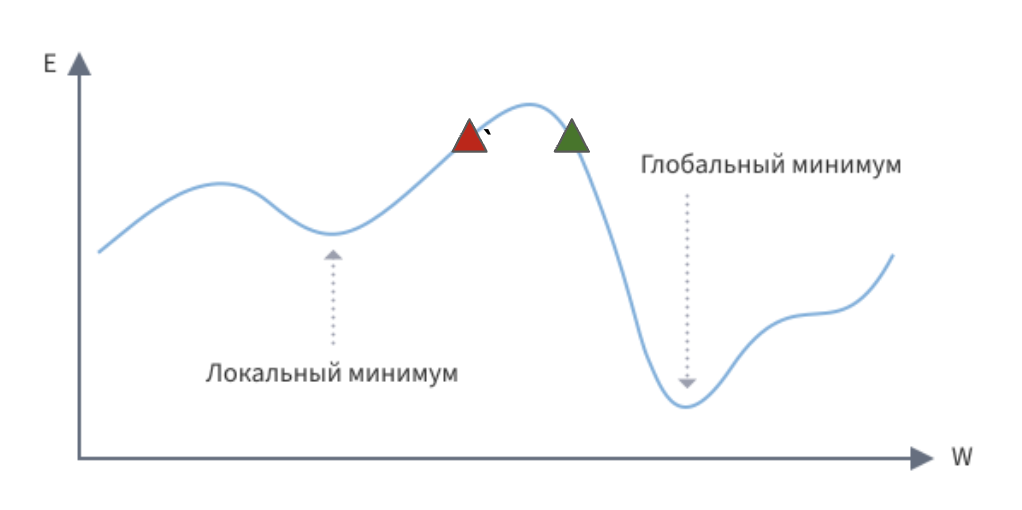


Решение — **стохастический градиентный спуск (SGD)**: обновления делаются по одному примеру, что ускоряет обучение и помогает "выбиваться" из локальных минимумов за счёт менее "достоверно оптимального" направления.

In [32]:
def stochastic_gradient_descent(
    X, y, lr=0.1, n_iter=1000, calc_loss=True, print_loss=False
):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    losses = []

    for i in range(n_iter):
        # случайный индекс примера
        idx = np.random.randint(0, n_samples)
        x_i = X[idx]
        y_i = y[idx]

        # предсказание
        y_pred = x_i @ weights

        # градиент (по одному примеру)
        error = y_pred - y_i
        grad = 2 * x_i * error

        # обновление весов
        weights -= lr * grad

        # для отслеживания динамики считаем полный лосс
        if calc_loss:
            y_full_pred = predict(X, weights)
            loss = mse_loss(y, y_full_pred)
            losses.append(loss)

            # промежуточные выводы на экран
            if print_loss and i % 10 == 0:
                print(f"Iteration {i}: MSE = {loss:.4f}")

    return weights, losses

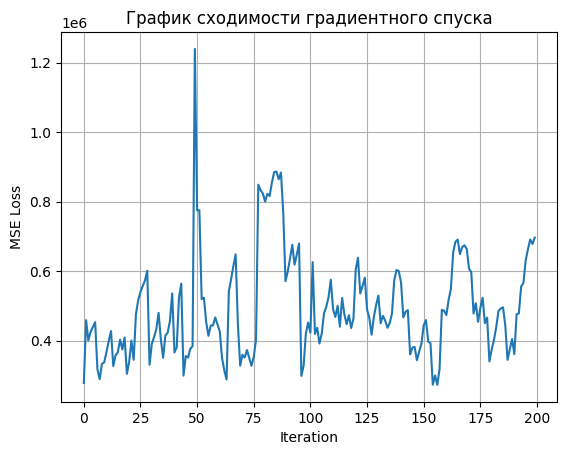

[ 541.23458493 -181.83157675 -287.95751224  175.8858645 ]


In [33]:
weights, losses = stochastic_gradient_descent(
    X_scaled, y, lr=0.1, n_iter=200, calc_loss=True, print_loss=False
)
plot_history(losses) # визуализация истории обучения
print(weights) # веса

# считаем предсказания
preds_gd = predict(X_scaled, weights)

Если видите слишком нестабильную картину - попробуйте уменьшить learning rate (шаг обучения).

Сравним время работы при прочих равных:

In [35]:
%%timeit
gradient_descent(X_scaled, y, lr=0.01, n_iter=1000, calc_loss=False, 
                                                    print_loss=False)

67.9 ms ± 724 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [37]:
%%timeit
stochastic_gradient_descent(X_scaled, y, lr=0.01, n_iter=1000, 
                                            calc_loss=False, print_loss=False)

10.4 ms ± 50.4 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
